# 2. Detekcja pierwszoplanowych obiektów ruchomych

In [1]:
from collections.abc import Sequence

from cv2.typing import MatLike
from IPython.display import clear_output, display
from matplotlib import pyplot as plt


def show_img(img: MatLike, cmap: str | None = None) -> None:
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

    
def show_sequence(img_sequence: Sequence[MatLike], cmap: str | None = None, wait_time: float = 1) -> None:
    frames = iter(img_sequence)
    first_frame = next(frames, None)
    if first_frame is None:
        return

    fig, ax = plt.subplots(figsize=(4, 4))
    image = ax.imshow(first_frame, cmap=cmap, vmin=0, vmax=255)
    ax.axis("off")

    try:
        display(fig)
        plt.pause(wait_time)

        for img in frames:
            image.set_data(img)
            clear_output(wait=True)
            display(fig)
            plt.pause(wait_time)
    finally:
        plt.close(fig)

In [2]:
TEST_IMG_INDEX = 349

## 2.1. Wczytywanie sekwencji obrazów

In [3]:
from enum import Enum


class DataSet(Enum):
    HIGHWAY="highway"
    OFFICE="office"
    PEDESTRIAN="pedestrian"

In [4]:
from collections.abc import Sequence
from pathlib import Path
from typing import NamedTuple

import cv2
import numpy as np
import re

class Roi(NamedTuple):
    start: int
    end: int

def _sorted_frame_paths(directory: Path, prefix: str) -> list[Path]:
    pattern = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    indexed_paths = []
    for path in directory.iterdir():
        if not path.is_file():
            continue
        match = pattern.fullmatch(path.stem)
        if match is None:
            continue
        indexed_paths.append((int(match.group(1)), path))
    return [path for _, path in sorted(indexed_paths, key=lambda item: item[0])]

def load_img_sequence(data_set: DataSet, *flags: int) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"input"
    return [np.astype(img, np.int16) for file_name in _sorted_frame_paths(dataset_dir, "in") if (img := cv2.imread(file_name, *flags)) is not None]

def load_img_sequence_results(data_set: DataSet) -> Sequence[MatLike]:
    dataset_dir = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"groundtruth"
    return [np.astype((img==255)*255, np.int16) for file_name in _sorted_frame_paths(dataset_dir, "gt") if (img := cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)) is not None]

def load_roi(data_set: DataSet) -> Roi:
    roi = Path(__name__).parent.resolve()/"data"/f"{data_set.value}"/"temporalROI.txt"
    return Roi(*[int(v) for v in roi.read_text("utf-8").split(" ")])

In [5]:
from dataclasses import dataclass
from itertools import pairwise


class CC(Enum):
    RETVAL = 0
    LABELS = 1
    STATS = 2
    CENTROIDS = 3


@dataclass(frozen=True)
class Metrics:
    tp: int
    tn: int
    fp: int
    fn: int

    def precision(self) -> float:
        if (buf := self.tp + self.fp) == 0:
            return 0.0
        return float(self.tp) / buf

    def recall(self) -> float:
        if (buf := self.tp + self.fn) == 0:
            return 0.0
        return float(self.tp) / buf

    def f1(self) -> float:
        precision = self.precision()
        recall = self.recall()
        if (buf := precision + recall) == 0:
            return 0.0
        return (2 * precision * recall) / buf

    @classmethod
    def compare_labels(cls, labels_pred: MatLike, labels_true: MatLike) -> 'Metrics':
        return cls(
            tp=np.sum((labels_true == 255) & (labels_pred == 255)),
            tn=np.sum((labels_true == 0) & (labels_pred == 0)),
            fp=np.sum((labels_true == 0) & (labels_pred == 255)),
            fn=np.sum((labels_true == 255) & (labels_pred == 0)),
        )


@dataclass(frozen=True)
class PipelineConfig:
    dataset: DataSet
    imread_flag: int = cv2.IMREAD_GRAYSCALE
    use_roi: bool = True
    gaussian_kernel: tuple[int, int] = (5, 5)
    gaussian_sigma: float = 1.5
    blur_iterations: int = 1
    threshold_value: float = 67
    threshold_max_value: float = 255
    threshold_mode: int = cv2.THRESH_TRIANGLE
    median_kernel_size: int = 5
    morph_shape: int = cv2.MORPH_ELLIPSE
    morph_kernel_size: tuple[int, int] = (7, 7)
    close_iterations: int = 0
    open_iterations: int = 1


@dataclass(frozen=True)
class PipelineResult:
    config: PipelineConfig
    roi: Roi
    frames: Sequence[MatLike]
    diff_sequence: Sequence[MatLike]
    gauss_sequence: Sequence[MatLike]
    binary_sequence: Sequence[MatLike]
    median_sequence: Sequence[MatLike]
    morph_sequence: Sequence[MatLike]
    cc_sequence: Sequence[tuple[int, MatLike, MatLike, MatLike]]
    biggest_label_sequence: Sequence[int]
    biggest_object_sequence: Sequence[MatLike]
    biggest_object_bbox_sequence: Sequence[MatLike]
    ground_truth_sequence: Sequence[MatLike]
    prediction_sequence: MatLike
    metrics_sequence: Sequence[Metrics]
    mean_precision: float
    mean_recall: float
    mean_f1: float


def run_pipeline(config: PipelineConfig) -> PipelineResult:
    frames = list(load_img_sequence(config.dataset, config.imread_flag))
    if not frames:
        raise ValueError(f"No input frames loaded for dataset '{config.dataset.value}'.")
    roi = load_roi(config.dataset) if config.use_roi else Roi(0, len(frames) - 1)

    diff_sequence = [
        cv2.absdiff(frames[i_left], frames[i_right]).astype(np.uint8)
        for i_left, i_right in pairwise(range(len(frames)))
    ]
    gauss_sequence = list(diff_sequence)
    for _ in range(config.blur_iterations):
        gauss_sequence = [
            cv2.GaussianBlur(img, config.gaussian_kernel, config.gaussian_sigma)
            for img in gauss_sequence
        ]
    binary_sequence = [
        cv2.threshold(
            img,
            config.threshold_value,
            config.threshold_max_value,
            config.threshold_mode,
        )[1]
        for img in gauss_sequence
    ]
    median_sequence = [
        cv2.medianBlur(img, ksize=config.median_kernel_size)
        for img in binary_sequence
    ]

    kernel = cv2.getStructuringElement(config.morph_shape, config.morph_kernel_size)
    morph_sequence = list(median_sequence)
    morph_sequence = [
        cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=config.close_iterations)
        for img in morph_sequence
    ]
    morph_sequence = [
        cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=config.open_iterations)
        for img in morph_sequence
    ]
    cc_sequence = [
        cv2.connectedComponentsWithStats(img)
        for img in morph_sequence
    ]
    biggest_label_sequence = [
        int(np.argmax(areas) + 1) if len((areas := img[CC.STATS.value][1:, cv2.CC_STAT_AREA])) > 0 else 0
        for img in cc_sequence
    ]
    biggest_object_sequence = [
        np.astype((img[CC.LABELS.value] == biggest) * 255, np.uint8)
        for img, biggest in zip(cc_sequence, biggest_label_sequence, strict=True)
    ]

    biggest_object_bbox_sequence = [
        np.repeat(np.clip(frame, 0, 255).astype(np.uint8)[..., None], 3, axis=2)
        if frame.ndim == 2
        else np.clip(frame, 0, 255).astype(np.uint8)
        for frame in frames
    ]
    for i, (img, biggest) in enumerate(zip(cc_sequence, biggest_label_sequence, strict=True), start=1):
        if biggest == 0:
            continue
        biggest_label_stats = img[CC.STATS.value][biggest]
        p1 = (int(biggest_label_stats[cv2.CC_STAT_LEFT]), int(biggest_label_stats[cv2.CC_STAT_TOP]))
        p2 = (
            int(p1[0] + biggest_label_stats[cv2.CC_STAT_WIDTH]),
            int(p1[1] + biggest_label_stats[cv2.CC_STAT_HEIGHT]),
        )
        cv2.rectangle(biggest_object_bbox_sequence[i], p1, p2, (255, 0, 0), 2)
    

    ground_truth_sequence = list(load_img_sequence_results(config.dataset))
    if not ground_truth_sequence:
        raise ValueError(f"No ground truth frames loaded for dataset '{config.dataset.value}'.")
    if len(ground_truth_sequence) != len(frames):
        raise ValueError(
            f"Input/groundtruth length mismatch for dataset '{config.dataset.value}': "
            f"{len(frames)} vs {len(ground_truth_sequence)}"
        )
    prediction_sequence = np.zeros_like(ground_truth_sequence)
    prediction_sequence[1:] = biggest_object_sequence

    metrics_sequence = [
        Metrics.compare_labels(prediction_sequence[i], ground_truth_sequence[i])
        for i in range(roi.start, roi.end)
    ]
    mean_precision = float(np.mean([m.precision() for m in metrics_sequence])) if metrics_sequence else 0.0
    mean_recall = float(np.mean([m.recall() for m in metrics_sequence])) if metrics_sequence else 0.0
    mean_f1 = float(np.mean([m.f1() for m in metrics_sequence])) if metrics_sequence else 0.0

    return PipelineResult(
        config=config,
        roi=roi,
        frames=frames,
        diff_sequence=diff_sequence,
        gauss_sequence=gauss_sequence,
        binary_sequence=binary_sequence,
        median_sequence=median_sequence,
        morph_sequence=morph_sequence,
        cc_sequence=cc_sequence,
        biggest_label_sequence=biggest_label_sequence,
        biggest_object_sequence=biggest_object_sequence,
        biggest_object_bbox_sequence=biggest_object_bbox_sequence,
        ground_truth_sequence=ground_truth_sequence,
        prediction_sequence=prediction_sequence,
        metrics_sequence=metrics_sequence,
        mean_precision=mean_precision,
        mean_recall=mean_recall,
        mean_f1=mean_f1,
    )


In [6]:
pipeline_config = PipelineConfig(dataset=DataSet.PEDESTRIAN)
pipeline_result = run_pipeline(pipeline_config)

start, stop = pipeline_result.roi
img_sequence = pipeline_result.frames
img_diff_sequence = pipeline_result.diff_sequence
img_gauss_sequence = pipeline_result.gauss_sequence
img_binary_sequence = pipeline_result.binary_sequence
img_median_sequence = pipeline_result.median_sequence
img_morph_sequence = pipeline_result.morph_sequence
img_cc_sequence = pipeline_result.cc_sequence
img_biggest_label_sequence = pipeline_result.biggest_label_sequence
img_biggest_object_sequence = pipeline_result.biggest_object_sequence
img_biggest_object_bbox_sequence = pipeline_result.biggest_object_bbox_sequence
img_sequence_result = pipeline_result.ground_truth_sequence
img_sequence_pred = pipeline_result.prediction_sequence
img_metrics_sequence = pipeline_result.metrics_sequence
mean_precision = pipeline_result.mean_precision
mean_recall = pipeline_result.mean_recall
mean_f1 = pipeline_result.mean_f1

len(img_sequence)


1099

In [7]:
show_sequence(img_sequence[start: stop+1], 'gray', wait_time=0.01)


KeyboardInterrupt: 

## 2.2. Odejmowanie ramek i binaryzacja

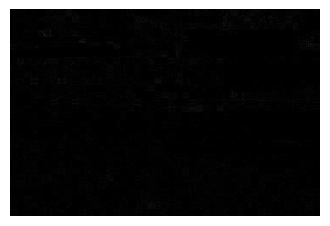

In [ ]:
show_sequence(img_diff_sequence[start: stop+1], 'gray', 0.01)

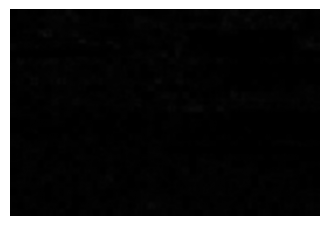

In [ ]:
show_sequence(img_gauss_sequence[start: stop+1], 'gray', 0.01)

In [ ]:
show_sequence(img_binary_sequence[start: stop+1], 'gray', 0.01)

## 2.3. Operacje morfologiczne

In [ ]:
show_sequence(img_median_sequence[start: stop+1], 'gray', 0.01)

In [ ]:
show_sequence(img_morph_sequence[start: stop+1], 'gray', 0.01)

KeyboardInterrupt: 

## 2.4. Indeksacja i prosta analiza

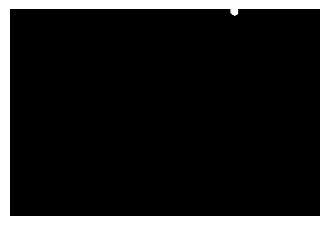

In [10]:
show_sequence(img_biggest_object_sequence[start: stop+1], "gray", 0.01)

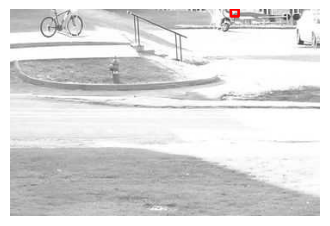

In [11]:
show_sequence(img_biggest_object_bbox_sequence[start: stop+1], None, 0.01)



## 2.5. Ewaluacja wyników detekcji obiektów pierwszoplanowych

In [ ]:
print(f"{len(img_biggest_object_sequence) = }")
print(f"{len(img_sequence_result) = }")
print(f"{start = }")
print(f"{stop = }")

len(img_biggest_object_sequence) = 1098
len(img_sequence_result) = 1099
start = 300
stop = 1099


In [ ]:
Metrics.compare_labels(img_sequence_pred[-1], img_sequence_result[-1])

Metrics(tp=np.int64(0), tn=np.int64(86339), fp=np.int64(61), fn=np.int64(0))

In [ ]:
print(mean_precision)
print(mean_recall)

0.32166404261149356
0.5770998032819898


In [ ]:
print(mean_f1)

0.40316430471768977


## Wyniki

In [ ]:
pedestrian_result = run_pipeline(PipelineConfig(
    dataset=DataSet.PEDESTRIAN,
    open_iterations=3,
    close_iterations=3,
))

print(f"{pedestrian_result.mean_recall = }")
print(f"{pedestrian_result.mean_precision = }")
print(f"{pedestrian_result.mean_f1 = }")

pedestrian_result.mean_recall = 0.6151495187386884
pedestrian_result.mean_precision = 0.36454381976586653
pedestrian_result.mean_f1 = 0.4444499648431611


In [ ]:
highway_result = run_pipeline(PipelineConfig(
    dataset=DataSet.HIGHWAY,
))

print(f"{highway_result.mean_recall = }")
print(f"{highway_result.mean_precision = }")
print(f"{highway_result.mean_f1 = }")

highway_result.mean_recall = 0.4940622408842371
highway_result.mean_precision = 0.6601830401089672
highway_result.mean_f1 = 0.5466821708860404


In [ ]:
office_result = run_pipeline(PipelineConfig(
    dataset=DataSet.OFFICE,
))

print(f"{office_result.mean_recall = }")
print(f"{office_result.mean_precision = }")
print(f"{office_result.mean_f1 = }")

office_result.mean_recall = 0.12397340923109289
office_result.mean_precision = 0.6662719967625398
office_result.mean_f1 = 0.18306048721700846
